In [67]:
# Description: This program uses an artificial recurrent neural network called Long Short Term Memory (LSTM) to predict 
#the closing stock price of a corporation (Apple Inc.) using the past 60 day stock price.

In [94]:
#Import the libraries
import math
import pandas_datareader as web
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, GRU
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [95]:
#Get the stock quote 
df = web.DataReader('AAPL', data_source='yahoo', start='2012-01-01', end='2020-11-24') 
#Show the data 
df

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2012-01-03,14.732142,14.607142,14.621428,14.686786,302220800.0,12.566676
2012-01-04,14.810000,14.617143,14.642858,14.765715,260022000.0,12.634213
2012-01-05,14.948215,14.738214,14.819643,14.929643,271269600.0,12.774481
2012-01-06,15.098214,14.972143,14.991786,15.085714,318292800.0,12.908023
2012-01-09,15.276786,15.048214,15.196428,15.061786,394024400.0,12.887549
...,...,...,...,...,...,...
2020-11-18,119.820000,118.000000,118.610001,118.029999,76322100.0,118.029999
2020-11-19,119.059998,116.809998,117.589996,118.639999,74113000.0,118.639999
2020-11-20,118.769997,117.290001,118.639999,117.339996,73391400.0,117.339996


In [70]:
df['Close']

Date
2012-01-03     14.686786
2012-01-04     14.765715
2012-01-05     14.929643
2012-01-06     15.085714
2012-01-09     15.061786
                 ...    
2020-11-18    118.029999
2020-11-19    118.639999
2020-11-20    117.339996
2020-11-23    113.849998
2020-11-24    115.169998
Name: Close, Length: 2240, dtype: float64

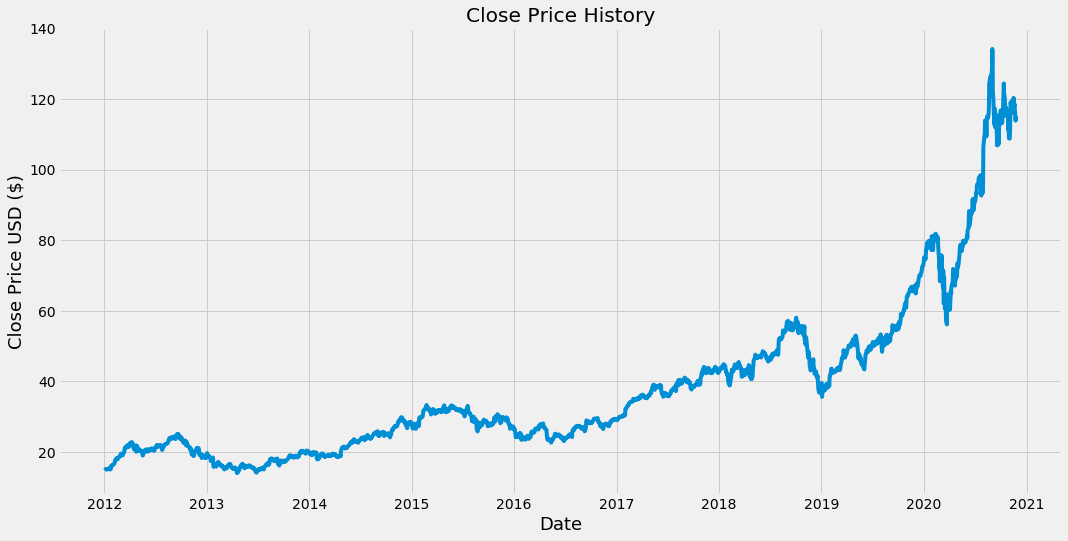

In [71]:
#Visualize the closing price history
plt.figure(figsize=(16,8))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date',fontsize=18)
plt.ylabel('Close Price USD ($)',fontsize=18)
plt.show()

In [72]:
#Create a new dataframe with only the 'Close' column
data = df.filter(['Close'])
#Converting the dataframe to a numpy array
dataset = data.values
#Get /Compute the number of rows to train the model on
training_data_len = math.ceil( len(dataset) *.8) 


In [73]:
#Scale the all of the data to be values between 0 and 1 
scaler = MinMaxScaler(feature_range=(0, 1)) 
scaled_data = scaler.fit_transform(dataset)
scaled_data

array([[0.0061488 ],
       [0.00680527],
       [0.00816869],
       ...,
       [0.85993806],
       [0.83091098],
       [0.84188971]])

In [74]:
#Create the scaled training data set 
train_data = scaled_data[0:training_data_len  , : ]
#Split the data into x_train and y_train data sets
x_train=[]
y_train = []
for i in range(60,len(train_data)):
    x_train.append(train_data[i-60:i,0])
    y_train.append(train_data[i,0])

In [75]:
x_train

[array([0.0061488 , 0.00680527, 0.00816869, 0.00946678, 0.00926776,
        0.00971629, 0.00951133, 0.00916676, 0.00869744, 0.01014998,
        0.01145994, 0.01105596, 0.00884299, 0.01095496, 0.00887566,
        0.01667305, 0.01607005, 0.01685722, 0.01855928, 0.01959001,
        0.01950387, 0.01918604, 0.02054056, 0.02181487, 0.02325851,
        0.0255903 , 0.03048855, 0.03056281, 0.03328967, 0.03532738,
        0.03182524, 0.03317382, 0.03314709, 0.03692846, 0.0363908 ,
        0.03738589, 0.0391741 , 0.0401692 , 0.04303567, 0.04512389,
        0.04572687, 0.04593778, 0.04236733, 0.04150589, 0.04163362,
        0.04499021, 0.04593482, 0.04796361, 0.05274602, 0.05912652,
        0.0579324 , 0.05793537, 0.06254846, 0.06399208, 0.06296431,
        0.06202567, 0.06104839, 0.06429507, 0.06652291, 0.06745562]),
 array([0.00680527, 0.00816869, 0.00946678, 0.00926776, 0.00971629,
        0.00951133, 0.00916676, 0.00869744, 0.01014998, 0.01145994,
        0.01105596, 0.00884299, 0.01095496, 0.

In [76]:
y_train

[0.06515055661523342,
 0.062088042929699744,
 0.06775563656793951,
 0.0709310214519843,
 0.06944283492600703,
 0.07222612922081767,
 0.07298359569819068,
 0.0706696330137738,
 0.07000425610876296,
 0.06898538532934267,
 0.06377524128776726,
 0.056319460106678265,
 0.06510302856031572,
 0.06469905595735218,
 0.058490838626342134,
 0.05419559377809535,
 0.05381536933875389,
 0.050423141670106336,
 0.06519215159520475,
 0.06450894373768143,
 0.06311284678406637,
 0.05746306823450234,
 0.056913544929312554,
 0.05805715305713663,
 0.05682145535695035,
 0.0518994461823542,
 0.05315594137252613,
 0.05276978385823833,
 0.05306683420147387,
 0.05346485786565433,
 0.05233313175155968,
 0.04981122589495954,
 0.04831115735525285,
 0.04620512197918242,
 0.04146430954800073,
 0.041541534705323596,
 0.05072017614950511,
 0.04943993279571107,
 0.053476739879383756,
 0.05192024367233988,
 0.051020193030213795,
 0.053984684068438926,
 0.056034291777172174,
 0.05560655514674978,
 0.05063403551592599,
 0.

In [77]:
#Convert x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

In [78]:
#Reshape the data into the shape accepted by the LSTM
x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))

In [79]:
x_train

array([[[0.0061488 ],
        [0.00680527],
        [0.00816869],
        ...,
        [0.06429507],
        [0.06652291],
        [0.06745562]],

       [[0.00680527],
        [0.00816869],
        [0.00946678],
        ...,
        [0.06652291],
        [0.06745562],
        [0.06515056]],

       [[0.00816869],
        [0.00946678],
        [0.00926776],
        ...,
        [0.06745562],
        [0.06515056],
        [0.06208804]],

       ...,

       [[0.27240973],
        [0.28199532],
        [0.28640344],
        ...,
        [0.23832992],
        [0.23629218],
        [0.23932798]],

       [[0.28199532],
        [0.28640344],
        [0.27045518],
        ...,
        [0.23629218],
        [0.23932798],
        [0.23785166]],

       [[0.28640344],
        [0.27045518],
        [0.25199094],
        ...,
        [0.23932798],
        [0.23785166],
        [0.23914085]]])

In [80]:
#Build the LSTM network model
model = Sequential()
model.add(GRU(units=50, return_sequences=True,input_shape=(x_train.shape[1],1)))
model.add(GRU(units=50, return_sequences=False))
model.add(Dense(units=25))
model.add(Dense(units=1))

In [81]:
#Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [82]:
#Train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)

1732/1732 [==============================] - 46s 26ms/step - loss: 1.3799e-04


In [83]:
#Test data set
test_data = scaled_data[training_data_len - 60: , : ]
#Create the x_test and y_test data sets
x_test = []
y_test =  dataset[training_data_len : , : ] #Get all of the rows from index 1603 to the rest and all of the columns (in this case it's only column 'Close'), so 2003 - 1603 = 400 rows of data
for i in range(60,len(test_data)):
    x_test.append(test_data[i-60:i,0])

In [84]:
#Convert x_test to a numpy array 
x_test = np.array(x_test)

In [85]:
#Reshape the data into the shape accepted by the LSTM
x_test = np.reshape(x_test, (x_test.shape[0],x_test.shape[1],1))

In [86]:
#Getting the models predicted price values
predictions = model.predict(x_test) 
predictions = scaler.inverse_transform(predictions)#Undo scaling

In [87]:
#Calculate/Get the value of RMSE
rmse=np.sqrt(np.mean(((predictions- y_test)**2)))
rmse

4.935709775886902

C:\Users\himal\Anaconda3\lib\site-packages\ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


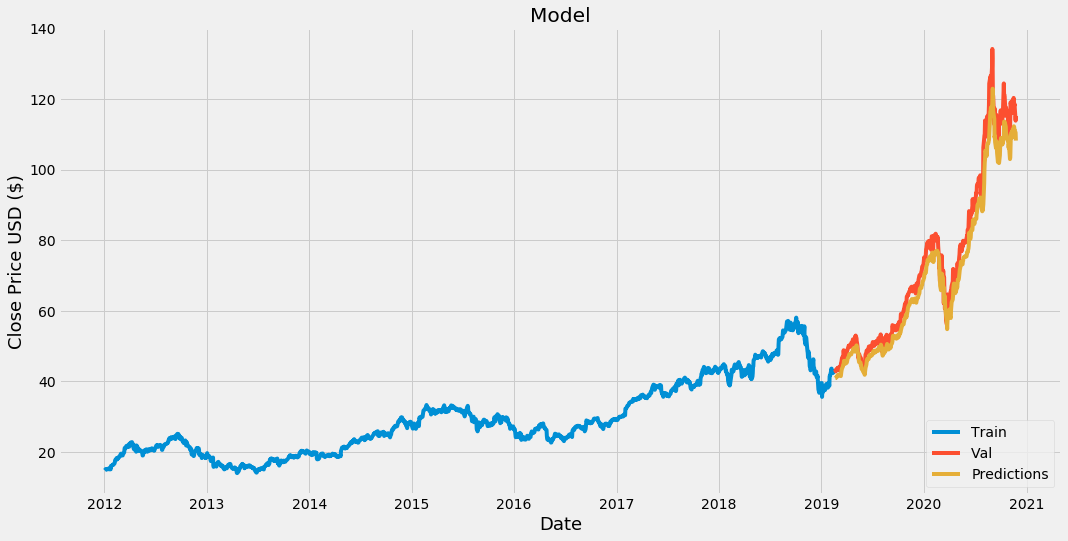

In [88]:
#Plot/Create the data for the graph
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
#Visualize the data
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()


In [89]:
#Show the valid and predicted prices
valid

,Close,Predictions
Date,,
2019-02-19,42.732498,40.813702
2019-02-20,43.007500,40.863758
2019-02-21,42.764999,41.026402
2019-02-22,43.242500,40.992947
2019-02-25,43.557499,41.197704
...,...,...
2020-11-18,118.029999,112.015320
2020-11-19,118.639999,111.134789
2020-11-20,117.339996,111.128197


In [90]:
#Get the quote
apple_quote = web.DataReader('AAPL', data_source='yahoo', start='2012-01-01', end='2020-11-24')
#Create a new dataframe
new_df = apple_quote.filter(['Close'])
#Get teh last 60 day closing price 
last_60_days = new_df[-60:].values
#Scale the data to be values between 0 and 1
last_60_days_scaled = scaler.transform(last_60_days)
#Create an empty list
X_test = []
#Append teh past 60 days
X_test.append(last_60_days_scaled)
#Convert the X_test data set to a numpy array
X_test = np.array(X_test)
#Reshape the data
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
#Get the predicted scaled price
pred_price = model.predict(X_test)
#undo the scaling 
pred_price = scaler.inverse_transform(pred_price)
print(pred_price)

[[108.04034]]


In [91]:
#Get the quote
apple_quote2 = web.DataReader('AAPL', data_source='yahoo', start='2020-11-25', end='2020-11-25')
print(apple_quote2['Close'])

Date
2020-11-24    115.169998
2020-11-25    116.029999
Name: Close, dtype: float64
